In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import colors as mcolors

ROOT = Path("/Users/andreali/Documents/Subgraph_Federated_Learning/")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from andrea.multigraph_generation import TASKS

VAL_TASKS_TO_PLOT = list(TASKS)

EXP_LOG_PATH = Path("./experiment_medium_graph_log.csv")
TEST_GEN_PATH = ROOT / Path("./andrea/test_generation_parameters.csv")

PLOTS_ROOT = Path.cwd() / "experiment_plots"

exp_log = pd.read_csv(EXP_LOG_PATH)
test_gen = pd.read_csv(TEST_GEN_PATH)

print("Loaded experiment rows:", len(exp_log))
print("Loaded generation rows:", len(test_gen))


Loaded experiment rows: 9
Loaded generation rows: 880


## General helpers

In [18]:
# ============================================================
# GENERAL HELPERS
# ============================================================

def stderr(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))

def resolve_existing_path(path_like):
    p = Path(path_like)
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    raise FileNotFoundError(f"Could not resolve path: {path_like}")

def load_run_csv(csv_path_like) -> pd.DataFrame:
    csv_path = resolve_existing_path(csv_path_like)
    return pd.read_csv(csv_path)

def safe_csv_exists(path_like):
    if path_like is None or pd.isna(path_like):
        return False
    try:
        return resolve_existing_path(path_like).exists()
    except FileNotFoundError:
        return False

def aggregate_curve(curves, x_col, y_col):
    if not curves:
        return pd.DataFrame(columns=[x_col, "mean", "std", "n"])
    df = pd.concat(curves, ignore_index=True)
    out = (
        df.groupby(x_col, as_index=False)[y_col]
          .agg(mean="mean", std="std", n="count")
          .sort_values(x_col)
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def aggregate_task_metric(task_df, metric_col):
    if task_df.empty:
        return pd.DataFrame(columns=["task", "mean", "std", "n"])
    out = (
        task_df.groupby(["task"], as_index=False)[metric_col]
               .agg(mean="mean", std="std", n="count")
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def aggregate_scalar_metric(scalar_df, metric_col):
    if scalar_df.empty:
        return pd.DataFrame(columns=["mean", "std", "n"])
    out = (
        scalar_df[[metric_col]]
        .agg(["mean", "std", "count"])
        .T
        .reset_index(drop=True)
    )
    out.columns = ["mean", "std", "n"]
    out["std"] = out["std"].fillna(0.0)
    return out

def aggregate_epoch_task_metric(task_df, metric_col):
    if task_df.empty:
        return pd.DataFrame(columns=["task", "local_epoch", "mean", "std", "n"])
    out = (
        task_df.groupby(["task", "local_epoch"], as_index=False)[metric_col]
               .agg(mean="mean", std="std", n="count")
               .sort_values(["task", "local_epoch"])
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def parse_subset_clients_str(s):
    return [int(x) for x in str(s).split("|") if str(x).strip() != ""]


def get_graph_meta_by_id(test_gen_df, graph_id):
    out = test_gen_df[test_gen_df["graph_id"].astype(int) == int(graph_id)]
    if out.empty:
        return None
    return out.iloc[0]


def get_task_split_stat(graph_row, split_name, task, kind):
    col = f"{split_name}_{task}_{kind}"
    if graph_row is None:
        return None
    if col in graph_row.index:
        return graph_row[col]
    return None

def show_selected_overview(selected, tasks):
    row = selected.iloc[0] if isinstance(selected, pd.DataFrame) else selected

    meta_cols = ["graph_id", "dataset_id", "type", "n", "d", "r"]
    for col in meta_cols:
        if col in row.index:
            print(f"{col}: {row[col]}")

    records = []
    for task in tasks:
        records.append(
            {
                "task": task,
                "train_pos_rate": get_task_split_stat(row, "train", task, "pos_rate"),
                "val_pos_rate": get_task_split_stat(row, "val", task, "pos_rate"),
                "test_pos_rate": get_task_split_stat(row, "test", task, "pos_rate"),
                "train_pos_nodes": get_task_split_stat(row, "train", task, "pos_nodes"),
                "val_pos_nodes": get_task_split_stat(row, "val", task, "pos_nodes"),
                "test_pos_nodes": get_task_split_stat(row, "test", task, "pos_nodes"),
            }
        )

    display(pd.DataFrame(records))


def build_graph_header(graph_row):
    return (
        f"graph_id={graph_row.get('graph_id', 'NA')} | "
        f"dataset={graph_row.get('dataset_id', 'NA')} | "
        f"type={graph_row.get('type', 'NA')} | "
        f"n={graph_row.get('n', 'NA')} | "
        f"d={graph_row.get('d', 'NA')} | "
        f"r={graph_row.get('r', 'NA')}"
    )


def build_split_header(graph_row, split_name):
    return (
        f"graph_id={graph_row.get('graph_id', 'NA')} | "
        f"dataset={graph_row.get('dataset_id', 'NA')} | "
        f"generator={graph_row.get('type', 'NA')} | "
        f"split={split_name}"
    )


def build_train_only_footer(graph_row, task_names, tasks_per_line=2):
    if graph_row is None:
        return "No graph metadata found in test_generation_parameters.csv"

    def fmt(x, nd=3):
        return "NA" if pd.isna(x) else f"{float(x):.{nd}f}"

    entries = []
    for task in task_names:
        tr_rate = get_task_split_stat(graph_row, "train", task, "pos_rate")
        tr_nodes = get_task_split_stat(graph_row, "train", task, "pos_nodes")
        entries.append(
            f"{task}: train(r={fmt(tr_rate)}, n={fmt(tr_nodes, 1)})"
        )

    lines = []
    for i in range(0, len(entries), tasks_per_line):
        lines.append(" | ".join(entries[i:i + tasks_per_line]))
    return "\n".join(lines)

def build_single_graph_footer(graph_row, task_names, tasks_per_line=2):
    if graph_row is None:
        return "No graph metadata found in test_generation_parameters.csv"

    entries = []
    for task in task_names:
        tr_rate = get_task_split_stat(graph_row, "train", task, "pos_rate")
        va_rate = get_task_split_stat(graph_row, "val", task, "pos_rate")
        te_rate = get_task_split_stat(graph_row, "test", task, "pos_rate")

        tr_nodes = get_task_split_stat(graph_row, "train", task, "pos_nodes")
        va_nodes = get_task_split_stat(graph_row, "val", task, "pos_nodes")
        te_nodes = get_task_split_stat(graph_row, "test", task, "pos_nodes")

        def fmt(x, nd=3):
            return "NA" if pd.isna(x) else f"{float(x):.{nd}f}"

        entries.append(
            f"{task}: "
            f"train(r={fmt(tr_rate)}, n={fmt(tr_nodes, 1)}) | "
            f"val(r={fmt(va_rate)}, n={fmt(va_nodes, 1)}) | "
            f"test(r={fmt(te_rate)}, n={fmt(te_nodes, 1)})"
        )

    lines = []
    for i in range(0, len(entries), tasks_per_line):
        lines.append("\n".join(entries[i:i + tasks_per_line]))
    return "\n\n".join(lines)

def build_pair_footer(test_gen_df, subset_clients_str, task_names):
    graph_ids = parse_subset_clients_str(subset_clients_str)
    if len(graph_ids) == 0:
        return "No subset_clients metadata found."

    blocks = []
    for gid in graph_ids:
        row = get_graph_meta_by_id(test_gen_df, gid)
        if row is None:
            blocks.append(f"graph_id={gid}: metadata not found")
            continue

        header = (
            f"graph_id={gid} | "
            f"dataset={row.get('dataset_id', 'NA')} | "
            f"type={row.get('type', 'NA')}"
        )

        task_lines = []
        for task in task_names:
            tr_rate = get_task_split_stat(row, "train", task, "pos_rate")
            va_rate = get_task_split_stat(row, "val", task, "pos_rate")
            te_rate = get_task_split_stat(row, "test", task, "pos_rate")

            def fmt(x):
                return "NA" if pd.isna(x) else f"{float(x):.3f}"

            task_lines.append(
                f"{task}: train={fmt(tr_rate)} | val={fmt(va_rate)} | test={fmt(te_rate)}"
            )

        blocks.append(header + "\n" + "\n".join(task_lines))

    return "\n\n" + ("-" * 80) + "\n\n".join(blocks)

## Data collection for plotting


In [19]:
# =============================
# DATA COLLECTION FOR PLOTTING
# =============================

def collect_local_runs(exp_log_df, graph_id):
    runs = exp_log_df[
        (exp_log_df["run_type"] == "local")
        & (exp_log_df["graph_id"].astype(str) == str(graph_id))
    ].copy()

    runs["run_csv"] = runs["out_csv"].apply(resolve_existing_path)
    runs["run_exists"] = runs["run_csv"].apply(lambda p: p.exists())
    return runs

def summarize_best_split_local(graph_runs, split_name):
    scalar_rows = []
    task_rows = []

    scalar_phase = f"best_local_{split_name}"
    task_phase = f"best_local_{split_name}_task"

    for _, run in graph_runs.iterrows():
        if not run["run_exists"]:
            continue

        local_df = load_run_csv(run["run_csv"])

        scalar_part = local_df[
            (local_df["phase"] == scalar_phase)
            & (local_df["task"].isna())
        ].copy()

        if not scalar_part.empty:
            row = scalar_part.iloc[-1].to_dict()
            row.update(
                {
                    "graph_id": run["graph_id"],
                    "seed": run["seed"],
                    "run_csv": str(run["run_csv"]),
                    "split_name": split_name,
                }
            )
            scalar_rows.append(row)

        task_part = local_df[local_df["phase"] == task_phase].copy()
        if not task_part.empty:
            task_part = task_part.assign(
                graph_id=run["graph_id"],
                seed=run["seed"],
                run_csv=str(run["run_csv"]),
                split_name=split_name,
            )
            task_rows.append(task_part)

    scalar_df = pd.DataFrame(scalar_rows)
    task_df = pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()
    return scalar_df, task_df

def summarize_val_task_per_epoch_local(graph_runs):
    task_rows = []

    for _, run in graph_runs.iterrows():
        if not run["run_exists"]:
            continue

        local_df = load_run_csv(run["run_csv"])
        part = local_df[local_df["phase"] == "val_epoch_task"].copy()
        if part.empty:
            continue

        part = part.assign(
            graph_id=run["graph_id"],
            seed=run["seed"],
            run_csv=str(run["run_csv"]),
        )
        task_rows.append(part)

    return pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()

## Figure builders


In [20]:
# ============================================================
# FIGURE BUILDERS (NEW LOGGING STYLE)
# ============================================================
def make_loss_figure_for_graph(
    graph_row,
    graph_runs,
    save_root,
    footer_text=None,
):
    fig, ax = plt.subplots(figsize=(10, 6))

    train_curves, val_curves = [], []

    for _, run in graph_runs.iterrows():
        if not run["run_exists"]:
            continue

        df = load_run_csv(run["run_csv"])

        train_df = df[
            (df["phase"] == "train_epoch")
            & (df["split"] == "train")
            & (df["task"].isna())
        ][["local_epoch", "train_loss"]].copy()

        val_df = df[
            (df["phase"] == "val_epoch")
            & (df["split"] == "val")
            & (df["task"].isna())
        ][["local_epoch", "eval_loss"]].copy()

        if not train_df.empty:
            train_curves.append(train_df.rename(columns={"train_loss": "metric"}))

        if not val_df.empty:
            val_curves.append(val_df.rename(columns={"eval_loss": "metric"}))

    if train_curves:
        train_agg = aggregate_curve(train_curves, "local_epoch", "metric")
        x = train_agg["local_epoch"].to_numpy(dtype=float)
        m = train_agg["mean"].to_numpy(dtype=float)
        s = train_agg["std"].to_numpy(dtype=float)
        ax.plot(x, m, marker="o", label="train_loss")
        ax.fill_between(x, m - s, m + s, alpha=0.2)

    if val_curves:
        val_agg = aggregate_curve(val_curves, "local_epoch", "metric")
        x = val_agg["local_epoch"].to_numpy(dtype=float)
        m = val_agg["mean"].to_numpy(dtype=float)
        s = val_agg["std"].to_numpy(dtype=float)
        ax.plot(x, m, marker="s", label="val_eval_loss")
        ax.fill_between(x, m - s, m + s, alpha=0.2)

    n_seeds = int(graph_runs["seed"].nunique()) if len(graph_runs) else 0
    ax.set_title(f"Loss curves\n(n_seeds={n_seeds})")
    ax.set_xlabel("local_epoch")
    ax.set_ylabel("loss")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.suptitle(build_graph_header(graph_row), y=0.98)

    if footer_text is not None:
        fig.text(0.01, 0.01, footer_text, ha="left", va="bottom", fontsize=11)
        fig.tight_layout(rect=[0, 0.10, 1, 0.93])
    else:
        fig.tight_layout(rect=[0, 0.03, 1, 0.93])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_losses.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path


def make_val_epoch_task_figure_for_graph(
    graph_row,
    task_df,
    save_root,
    task_subset=None,
):
    if task_subset is None:
        task_subset = list(TASKS)

    if task_df.empty:
        print("No val_epoch_task rows found.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), squeeze=False)
    axes = axes.flatten()

    metric_specs = [
        ("f1", "Validation Positive F1 vs Epoch"),
        ("minority_f1", "Validation Minority F1 vs Epoch"),
    ]

    agg_cache = {
        "f1": aggregate_epoch_task_metric(task_df, "f1"),
        "minority_f1": aggregate_epoch_task_metric(task_df, "minority_f1"),
    }

    for ax, (metric_col, title) in zip(axes, metric_specs):
        agg = agg_cache[metric_col]

        for task in task_subset:
            task_part = agg[agg["task"] == task].sort_values("local_epoch")
            if task_part.empty:
                continue

            x = task_part["local_epoch"].to_numpy(dtype=float)
            m = task_part["mean"].to_numpy(dtype=float)
            s = task_part["std"].to_numpy(dtype=float)

            ax.plot(x, m, marker="o", label=task)
            ax.fill_between(x, m - s, m + s, alpha=0.2)

        ax.set_title(title)
        ax.set_xlabel("local_epoch")
        ax.set_ylabel(metric_col)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(build_graph_header(graph_row), y=0.98)
    fig.tight_layout(rect=[0, 0.03, 1, 0.94])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_val_task_epoch_curves.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path


def make_task_metric_table_for_graph(
    graph_row,
    task_df,
    save_root,
    split_name,
):
    if task_df.empty:
        print("No task metrics available.")
        return None

    metric_specs = [
        ("positive_f1", "Positive F1"),
        ("minority_f1", "Minority F1"),
    ]
    task_order = list(TASKS)

    row_labels = []
    value_rows = []
    text_rows = []

    for metric_col, metric_label in metric_specs:
        agg = aggregate_task_metric(task_df, metric_col)

        row_vals = []
        row_txts = []
        for task in task_order:
            row = agg[agg["task"] == task]
            if row.empty:
                mean_v = np.nan
                std_v = np.nan
            else:
                mean_v = float(row["mean"].iloc[0])
                std_v = float(row["std"].iloc[0])

            row_vals.append(mean_v if np.isfinite(mean_v) else 0.0)
            if np.isfinite(mean_v):
                row_txts.append(f"{mean_v:.3f}\n±{0.0 if not np.isfinite(std_v) else std_v:.3f}")
            else:
                row_txts.append("NA")

        row_labels.append(metric_label)
        value_rows.append(row_vals)
        text_rows.append(row_txts)

    value_mat = np.asarray(value_rows, dtype=float)

    fig_height = max(3.8, 0.75 * len(row_labels) + 2.0)
    fig_width = max(10, 1.25 * len(task_order) + 2.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    _draw_heat_table(
        ax=ax,
        color_values=value_mat,
        text_values=text_rows,
        row_labels=row_labels,
        col_labels=task_order,
        title=f"{split_name.upper()} task metrics",
        cmap="Greens",
        vmin=0.0,
        vmax=1.0,
        fontsize=11,
    )

    fig.suptitle(
        build_split_header(graph_row, split_name),
        y=0.98,
        fontsize=15,
    )

    fig.tight_layout(rect=[0, 0.03, 1, 0.92])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_task_table.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path


def make_scalar_metric_table_for_graph(
    graph_row,
    scalar_df,
    save_root,
    split_name,
):
    if scalar_df.empty:
        print("No scalar metrics available.")
        return None

    metric_specs = [
        ("local_epoch", "best_epoch", 1),
        ("eval_loss", "eval_loss", 4),
        ("micro_f1", "micro_f1", 3),
        ("macro_pos_f1", "macro_pos_f1", 3),
        ("macro_minority_f1", "macro_minority_f1", 3),
    ]

    row_labels = ["mean±std"]
    col_labels = [label for _, label, _ in metric_specs]

    row_vals = []
    row_txts = []

    for metric_col, _, decimals in metric_specs:
        agg = aggregate_scalar_metric(scalar_df, metric_col)

        if agg.empty:
            mean_v = np.nan
            std_v = np.nan
        else:
            mean_v = float(agg["mean"].iloc[0])
            std_v = float(agg["std"].iloc[0])

        row_vals.append(mean_v if np.isfinite(mean_v) else np.nan)

        if np.isfinite(mean_v):
            row_txts.append(
                f"{mean_v:.{decimals}f}\n±{0.0 if not np.isfinite(std_v) else std_v:.{decimals}f}"
            )
        else:
            row_txts.append("NA")

    value_mat = np.asarray([row_vals], dtype=float)
    color_mat = _columnwise_color_matrix(
        values=value_mat,
        col_labels=col_labels,
        lower_is_better_cols={"eval_loss"},
        neutral_cols={"best_epoch"},
    )

    fig_height = 3.8
    fig_width = max(10.5, 1.7 * len(col_labels))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    _draw_heat_table(
        ax=ax,
        color_values=color_mat,
        text_values=[row_txts],
        row_labels=row_labels,
        col_labels=col_labels,
        title=f"{split_name.upper()} scalar metrics",
        cmap="Greens",
        vmin=0.0,
        vmax=1.0,
        fontsize=11,
    )

    fig.suptitle(
        build_split_header(graph_row, split_name),
        y=0.98,
        fontsize=15,
    )

    fig.tight_layout(rect=[0, 0.03, 1, 0.92])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_scalar_table.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path

def _text_color_from_norm(x, threshold=0.58):
    return "white" if x >= threshold else "black"


def _draw_heat_table(
    ax,
    color_values,
    text_values,
    row_labels,
    col_labels,
    title="",
    cmap="Greens",
    vmin=0.0,
    vmax=1.0,
    fontsize=11,
):
    cmap_obj = plt.get_cmap(cmap)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    nrows, ncols = color_values.shape
    ax.imshow(color_values, cmap=cmap_obj, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(ncols))
    ax.set_yticks(np.arange(nrows))
    ax.set_xticklabels(col_labels, fontsize=fontsize)
    ax.set_yticklabels(row_labels, fontsize=fontsize)

    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    for i in range(nrows):
        for j in range(ncols):
            val = color_values[i, j]
            txt = text_values[i][j]
            txt_color = _text_color_from_norm(norm(val))
            ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                color=txt_color,
                fontsize=fontsize,
                linespacing=1.2,
            )

    ax.set_title(title, fontsize=fontsize + 1)
    for spine in ax.spines.values():
        spine.set_visible(False)


def _columnwise_color_matrix(
    values,
    col_labels,
    lower_is_better_cols=None,
    neutral_cols=None,
):
    if lower_is_better_cols is None:
        lower_is_better_cols = set()
    if neutral_cols is None:
        neutral_cols = set()

    values = np.asarray(values, dtype=float)
    out = np.full_like(values, 0.5, dtype=float)

    for j, col in enumerate(col_labels):
        if col in neutral_cols:
            out[:, j] = 0.5
            continue

        col_vals = values[:, j]
        finite = np.isfinite(col_vals)

        if finite.sum() == 0:
            out[:, j] = 0.5
            continue

        vmin = np.nanmin(col_vals[finite])
        vmax = np.nanmax(col_vals[finite])

        if abs(vmax - vmin) < 1e-12:
            out[:, j] = 0.92
            continue

        normed = (col_vals - vmin) / (vmax - vmin)

        if col in lower_is_better_cols:
            normed = 1.0 - normed

        out[:, j] = normed

    return out

## Runner

This is the only cell that actually executes the pipeline end-to-end.  
If you add a new figure type later, wire it into `run_all_plots()` here.



graph_id: 1
dataset_id: data_4000_5_11.5_chordal
type: chordal
n: 4000
d: 5
r: 11.5


,task,train_pos_rate,val_pos_rate,test_pos_rate,train_pos_nodes,val_pos_nodes,test_pos_nodes
0,cycle2,0.14375,0.14125,0.13250,575,565,530
1,cycle3,0.21900,0.21300,0.22775,876,852,911
2,cycle4,0.34650,0.35075,0.32925,1386,1403,1317
3,cycle5,0.47250,0.47450,0.45150,1890,1898,1806
4,cycle6,0.56875,0.55000,0.57025,2275,2200,2281


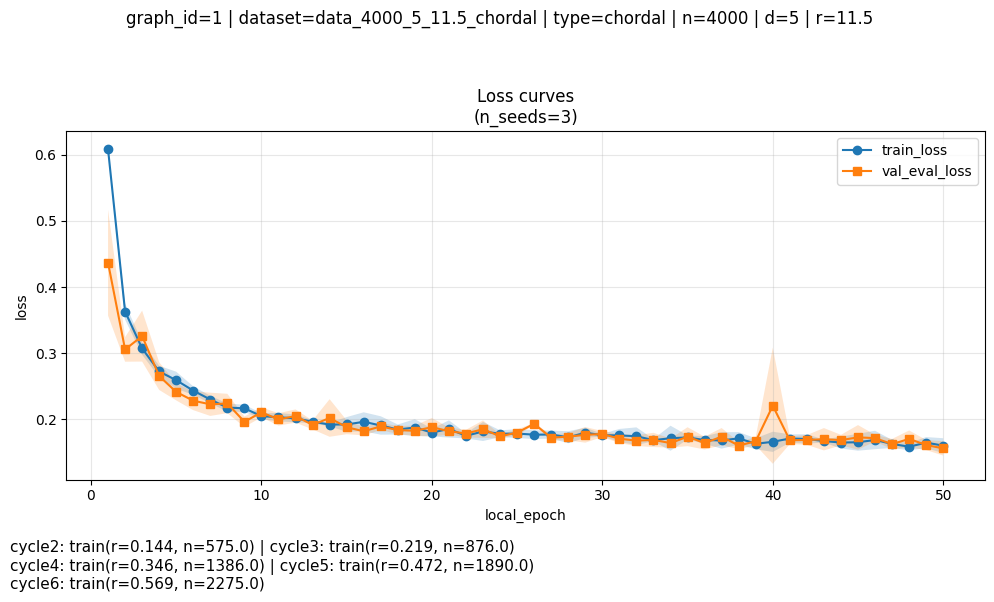

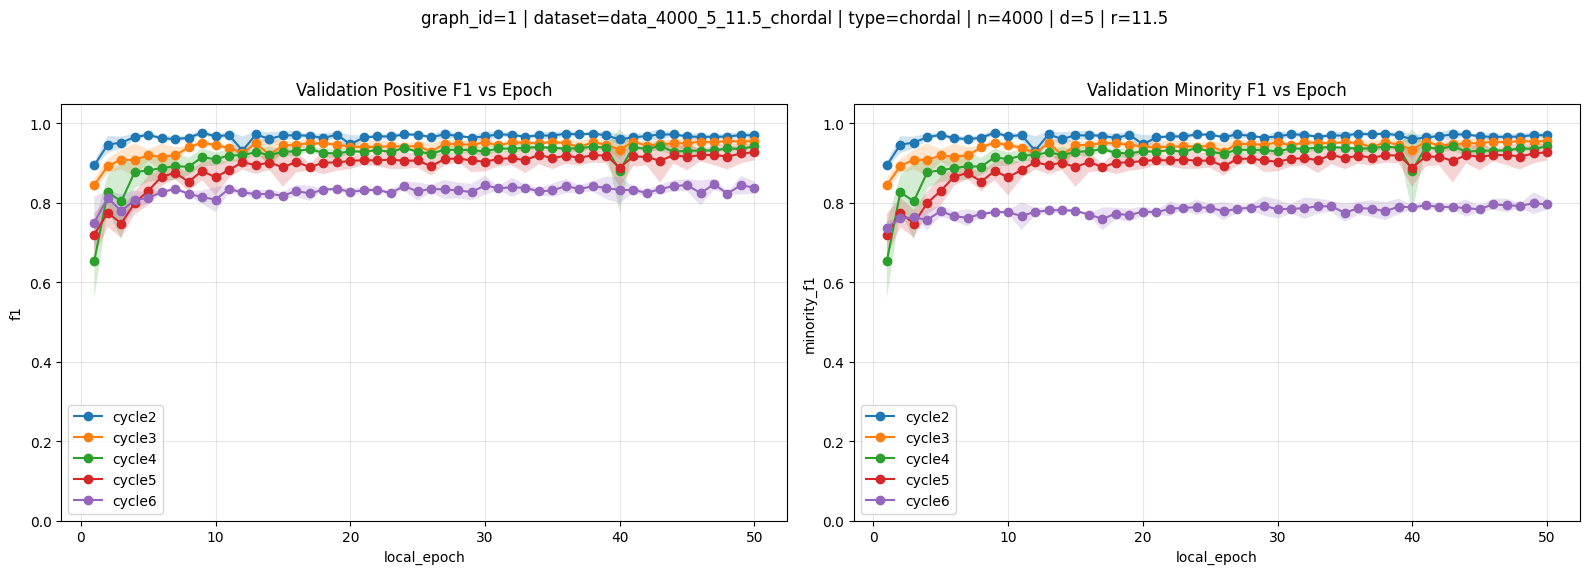

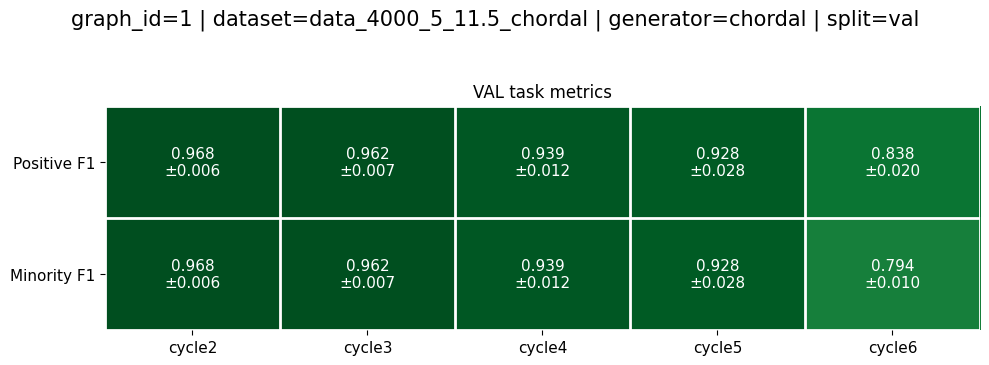

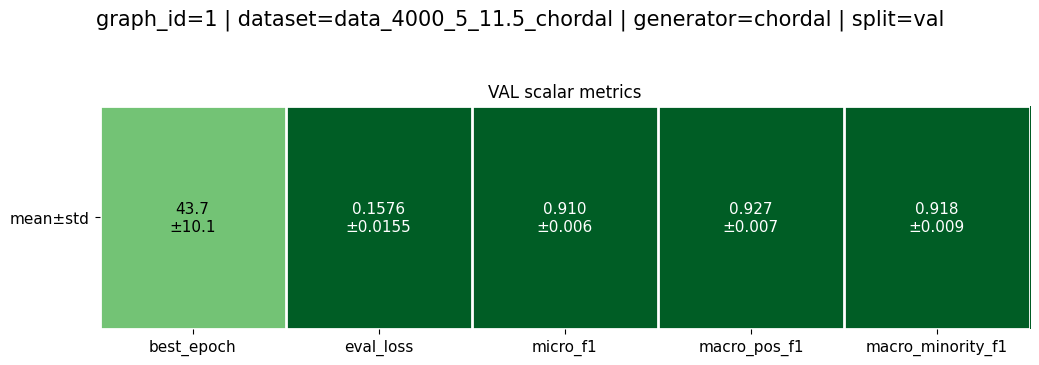

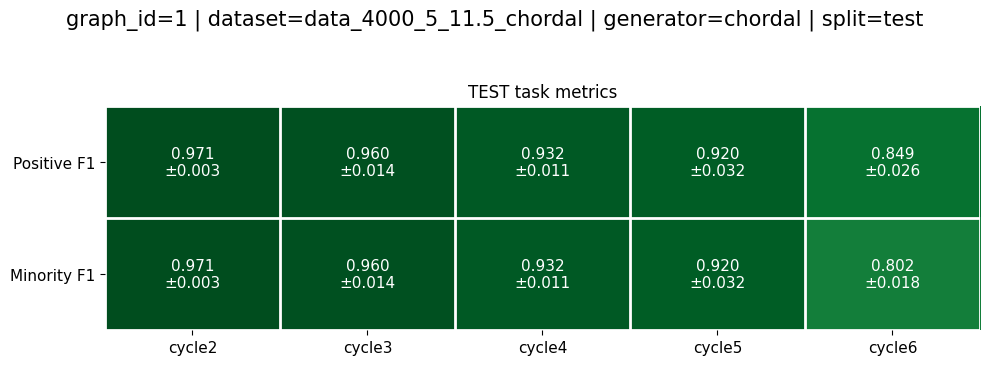

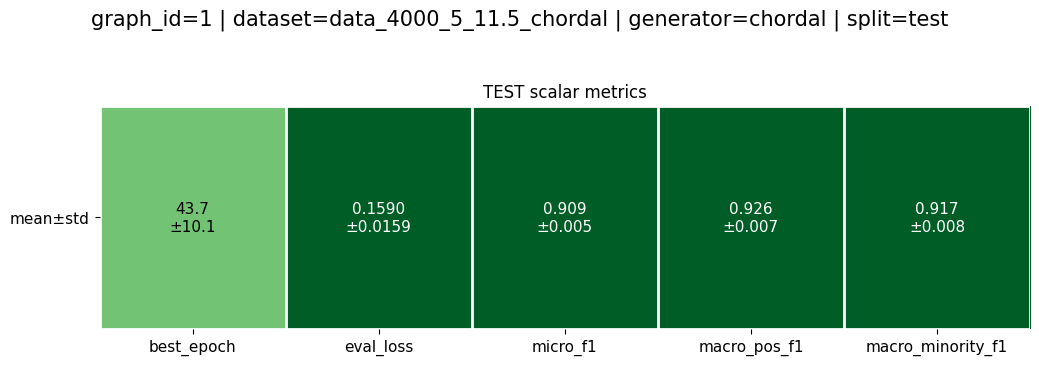


graph_id: 141
dataset_id: data_4000_5_2.5_chordal
type: chordal
n: 4000
d: 5
r: 2.5


,task,train_pos_rate,val_pos_rate,test_pos_rate,train_pos_nodes,val_pos_nodes,test_pos_nodes
0,cycle2,0.44825,0.44625,0.42975,1793,1785,1719
1,cycle3,0.46075,0.45575,0.48850,1843,1823,1954
2,cycle4,0.47200,0.46825,0.49675,1888,1873,1987
3,cycle5,0.45800,0.42375,0.48275,1832,1695,1931
4,cycle6,0.41750,0.41000,0.42800,1670,1640,1712


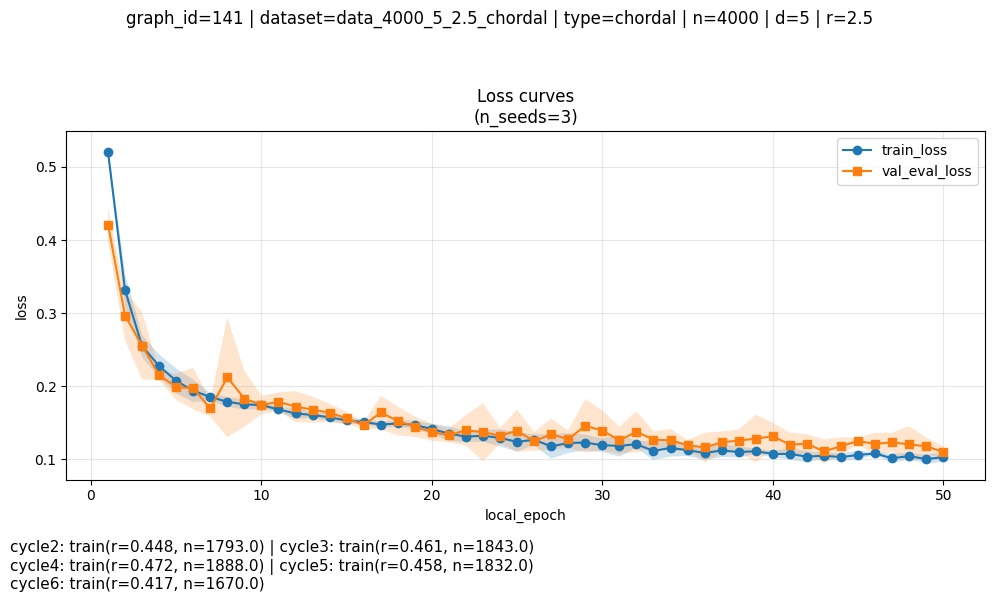

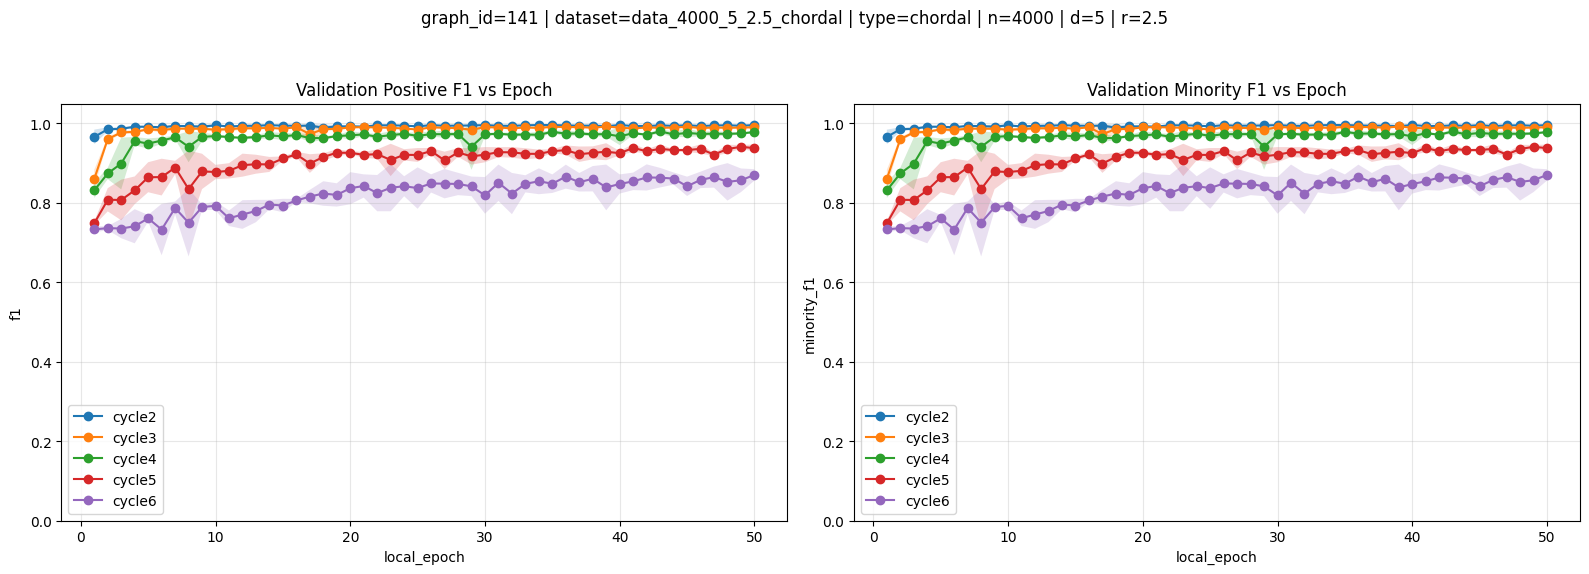

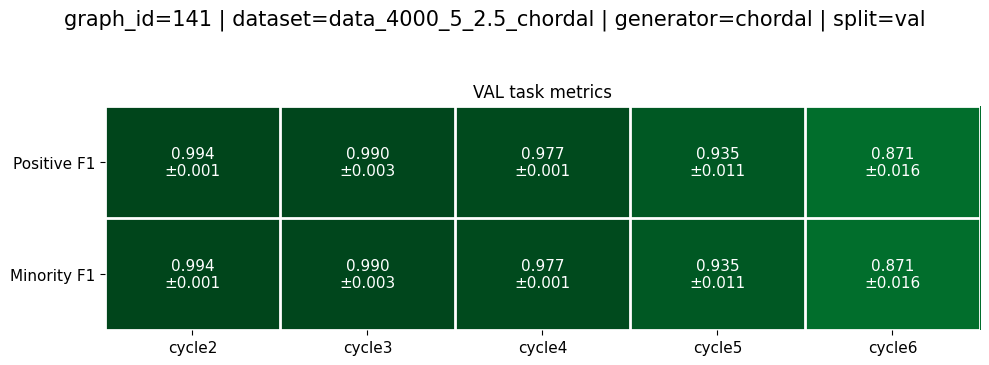

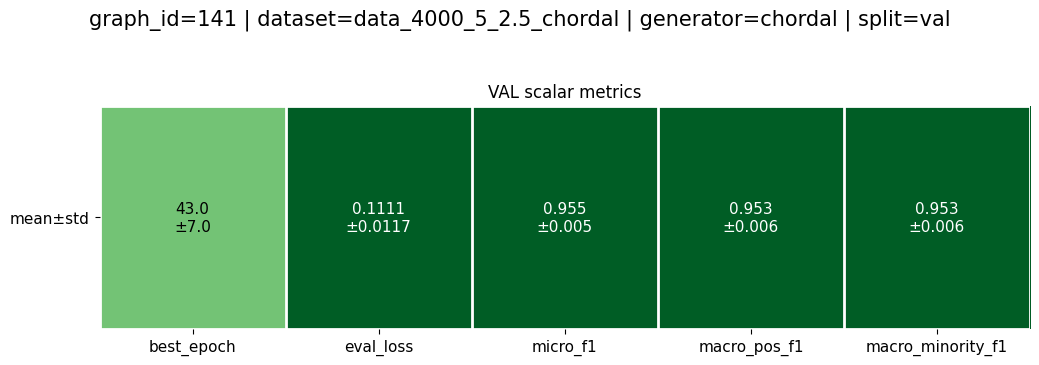

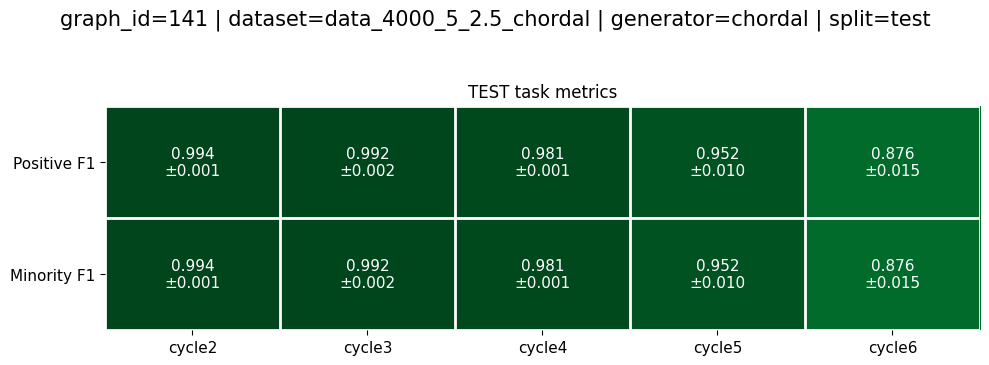

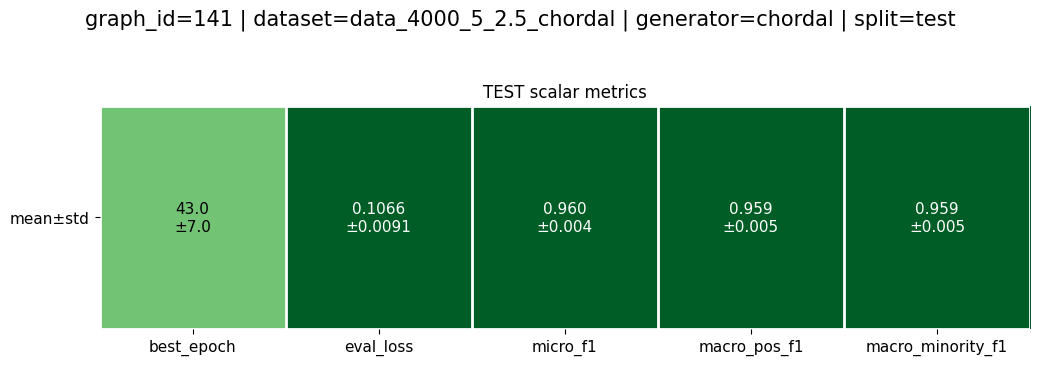


graph_id: 467
dataset_id: data_4000_5_1.5_chordal
type: chordal
n: 4000
d: 5
r: 1.5


,task,train_pos_rate,val_pos_rate,test_pos_rate,train_pos_nodes,val_pos_nodes,test_pos_nodes
0,cycle2,0.55775,0.56200,0.56100,2231,2248,2244
1,cycle3,0.48100,0.49775,0.50450,1924,1991,2018
2,cycle4,0.37650,0.38500,0.39050,1506,1540,1562
3,cycle5,0.27700,0.26850,0.25450,1108,1074,1018
4,cycle6,0.15700,0.16000,0.15025,628,640,601


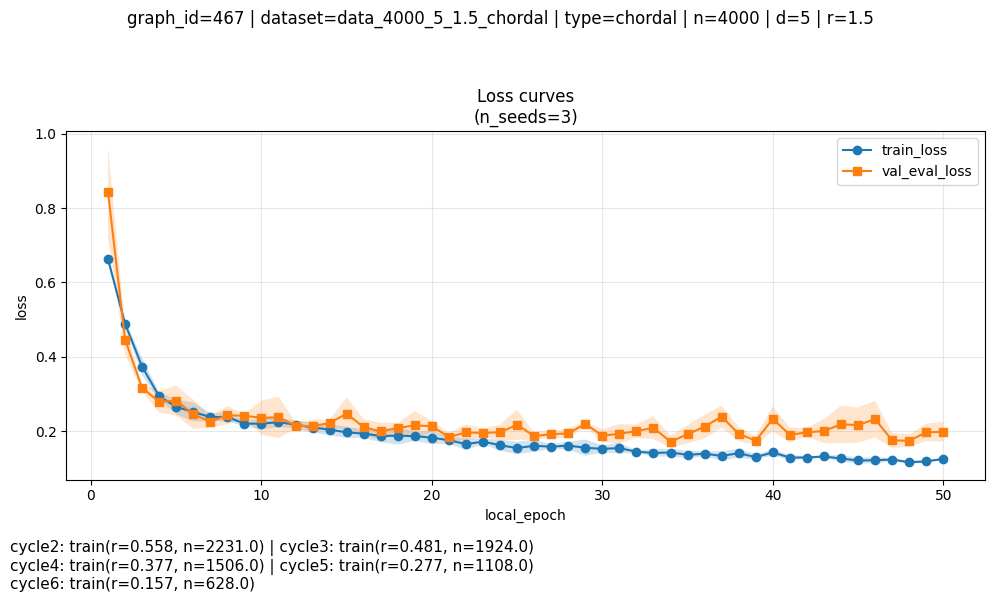

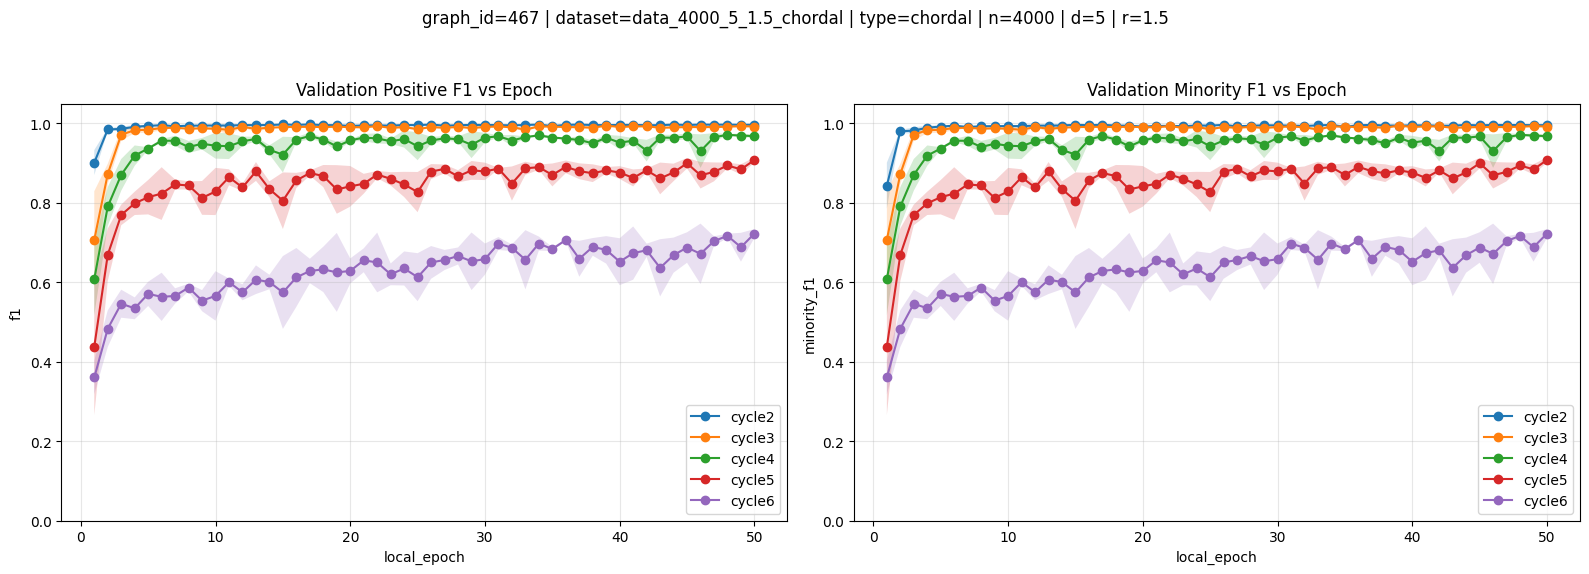

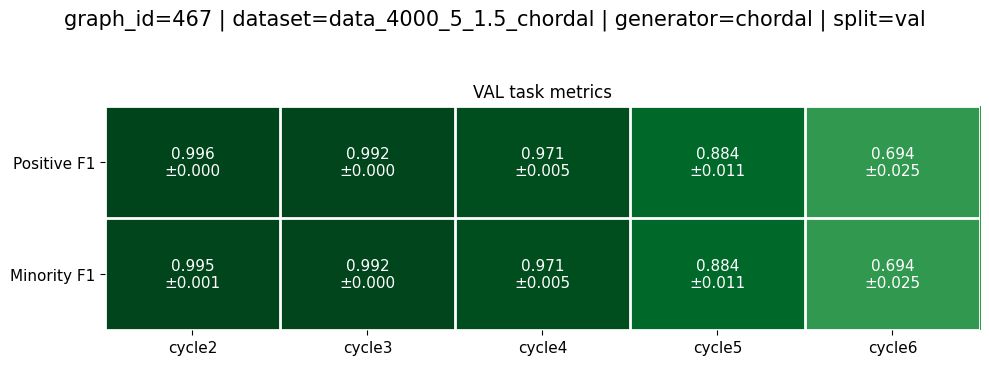

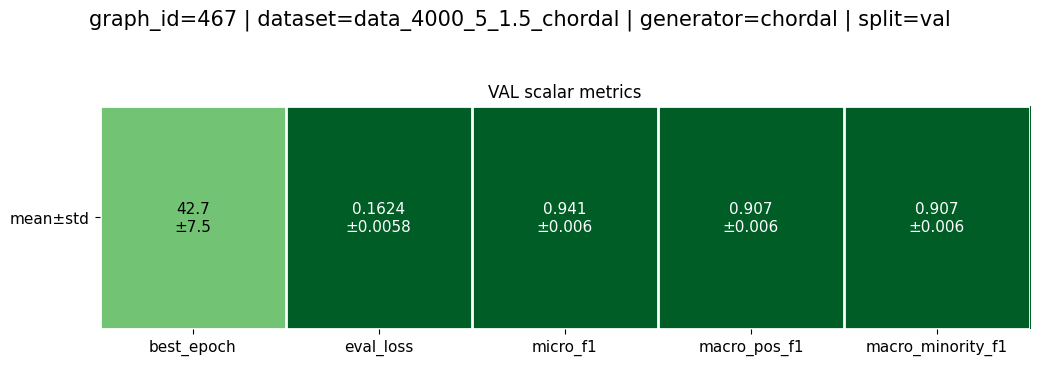

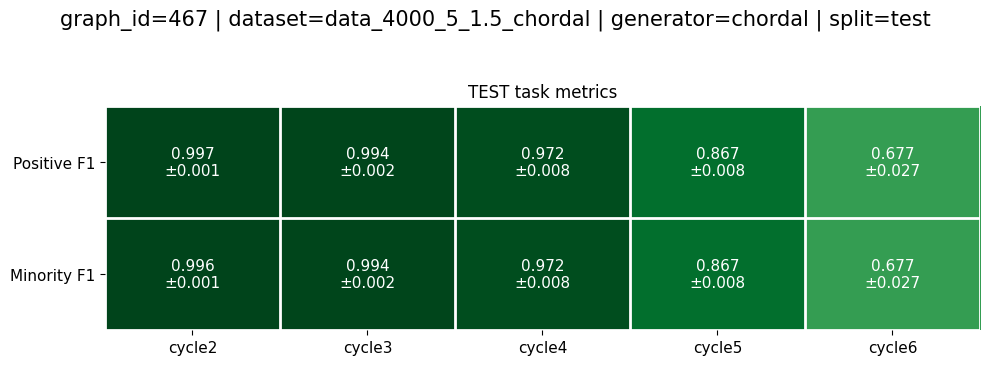

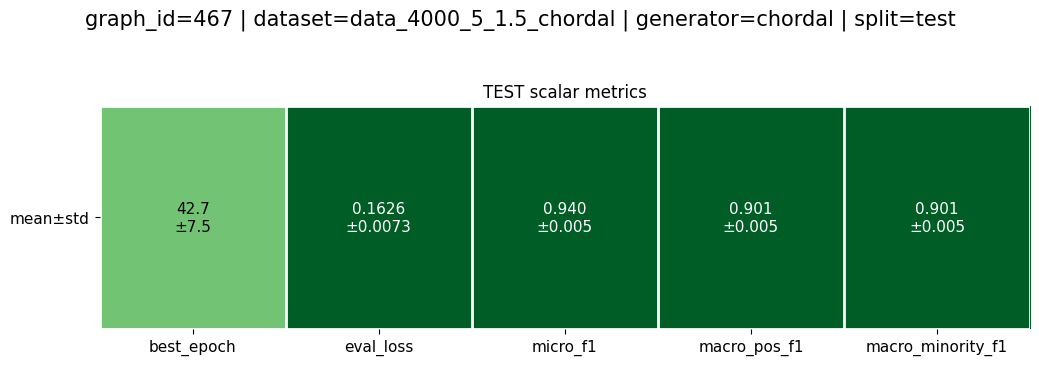

In [21]:
# ============================================================
# MAIN RUNNER (LOCAL, NEW STYLE)
# ============================================================

def run_all_plots(
    exp_log_df,
    graph_meta_df,
    plots_root,
    val_tasks_to_plot=None,
):
    if val_tasks_to_plot is None:
        val_tasks_to_plot = list(TASKS)

    plots_root.mkdir(parents=True, exist_ok=True)

    saved = {
        "loss": [],
        "val_epoch_task": [],
        "val_task_table": [],
        "val_scalar_table": [],
        "test_task_table": [],
        "test_scalar_table": [],
    }

    local_graph_ids = (
        exp_log_df.loc[exp_log_df["run_type"] == "local", "graph_id"]
        .dropna()
        .astype(int)
        .drop_duplicates()
        .tolist()
    )

    for graph_id in local_graph_ids:
        print("\n" + "=" * 110)

        graph_row = get_graph_meta_by_id(graph_meta_df, graph_id)
        if graph_row is None:
            print(f"graph_id={graph_id}: metadata not found in test_generation_parameters.csv")
            continue

        show_selected_overview(graph_row, TASKS)

        graph_runs = collect_local_runs(exp_log_df, graph_id)
        if graph_runs["run_exists"].sum() == 0:
            print("No local run CSVs found for this graph.")
            print(f"graph_id={graph_id}")
            continue

        graph_runs = graph_runs[graph_runs["run_exists"]].copy()

        # keep whichever footer helper you want for the loss plot
        # if you added the train-only footer helper, use that here
        footer_text = build_train_only_footer(
            graph_row=graph_row,
            task_names=TASKS,
            tasks_per_line=2,
        )

        loss_plot_path = make_loss_figure_for_graph(
            graph_row,
            graph_runs,
            plots_root,
            footer_text=footer_text,
        )
        saved["loss"].append(loss_plot_path)

        val_task_epoch_df = summarize_val_task_per_epoch_local(graph_runs)
        if not val_task_epoch_df.empty:
            val_epoch_plot_path = make_val_epoch_task_figure_for_graph(
                graph_row,
                val_task_epoch_df,
                plots_root,
                task_subset=val_tasks_to_plot,
            )
            if val_epoch_plot_path is not None:
                saved["val_epoch_task"].append(val_epoch_plot_path)
        else:
            print("No val_epoch_task rows found for per-epoch validation task plot.")

        for split_name, task_key, scalar_key in [
            ("val", "val_task_table", "val_scalar_table"),
            ("test", "test_task_table", "test_scalar_table"),
        ]:
            scalar_df, task_df = summarize_best_split_local(graph_runs, split_name)

            if not task_df.empty:
                task_plot_path = make_task_metric_table_for_graph(
                    graph_row=graph_row,
                    task_df=task_df,
                    save_root=plots_root,
                    split_name=split_name,
                )
                saved[task_key].append(task_plot_path)
            else:
                print(f"No best_local_{split_name}_task rows found.")

            if not scalar_df.empty:
                scalar_plot_path = make_scalar_metric_table_for_graph(
                    graph_row=graph_row,
                    scalar_df=scalar_df,
                    save_root=plots_root,
                    split_name=split_name,
                )
                saved[scalar_key].append(scalar_plot_path)
            else:
                print(f"No best_local_{split_name} rows found.")

    return saved


saved_plots = run_all_plots(
    exp_log_df=exp_log,
    graph_meta_df=test_gen,
    plots_root=PLOTS_ROOT,
    val_tasks_to_plot=VAL_TASKS_TO_PLOT,
)